# 🦠 Análise COVID-19 com Google BigQuery + Google Colab

Este notebook tem como objetivo **analisar os impactos proporcionais da pandemia de COVID-19 no Brasil**, com base em dados públicos processados no **Google BigQuery** e visualizados no **Google Colab**.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leitura do arquivo CSV (exportado do BigQuery)
df = pd.read_csv("tbl_resultado_covid.csv")

# Verifica colunas disponíveis
print("Colunas:", df.columns)

# Normalização de nomes (por segurança)
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

# Converter ano_mes para datetime (caso esteja como string)
df['ano_mes'] = pd.to_datetime(df['ano_mes'], format='%Y-%m')

# Ordenar por ano_mes de forma global (isso ajuda em gráficos e filtros)
df = df.sort_values(by='ano_mes')

Colunas: Index(['date', 'ano_mes', 'state', 'city', 'city_code', 'cases', 'deaths',
       'region', 'population', 'taxa_mortalidade_10k', 'taxa_mortalidade_100k',
       'incidencia_100k', 'letalidade_percentual',
       'densidade_casos_por_habitante', 'percentual_contaminados',
       'percentual_mortes_populacao'],
      dtype='object')


## GRÁFICO 1: Maiores taxas de mortalidade por 100 mil habitantes por estado (último mês)


C:\Users\jean_\AppData\Local\Temp\ipykernel_155352\4236437098.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mort_estados.values, y=mort_estados.index, palette="Reds_r")


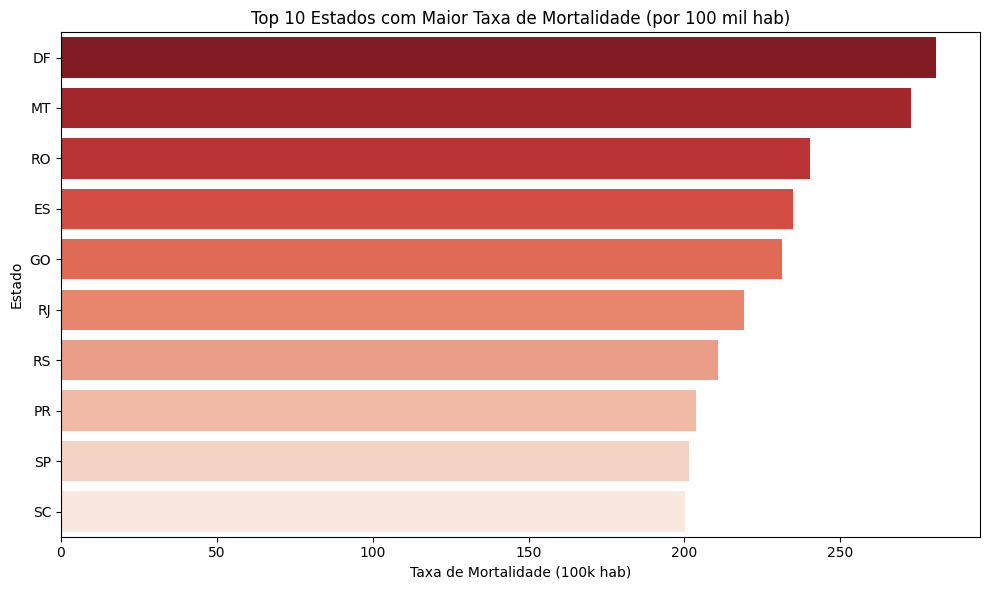

In [3]:
df_ultimo_mes = df[df['ano_mes'] == df['ano_mes'].max()]
mort_estados = df_ultimo_mes.groupby('state')['taxa_mortalidade_100k'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=mort_estados.values, y=mort_estados.index, palette="Reds_r")
plt.title('Top 10 Estados com Maior Taxa de Mortalidade (por 100 mil hab)')
plt.xlabel('Taxa de Mortalidade (100k hab)')
plt.ylabel('Estado')
plt.tight_layout()
plt.show()

## GRÁFICO 2: Dispersão entre densidade de casos e percentual contaminado

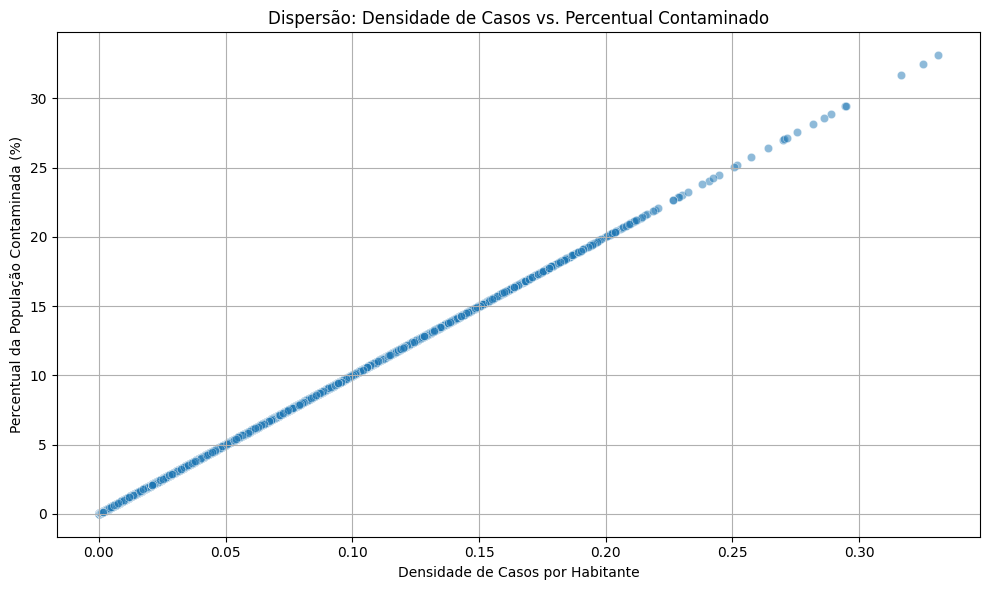

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='densidade_casos_por_habitante',
    y='percentual_contaminados',
    alpha=0.5
)
plt.title('Dispersão: Densidade de Casos vs. Percentual Contaminado')
plt.xlabel('Densidade de Casos por Habitante')
plt.ylabel('Percentual da População Contaminada (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

## GRÁFICO 3: Evolução temporal de casos e mortes de uma cidade


### Rio de Janeiro

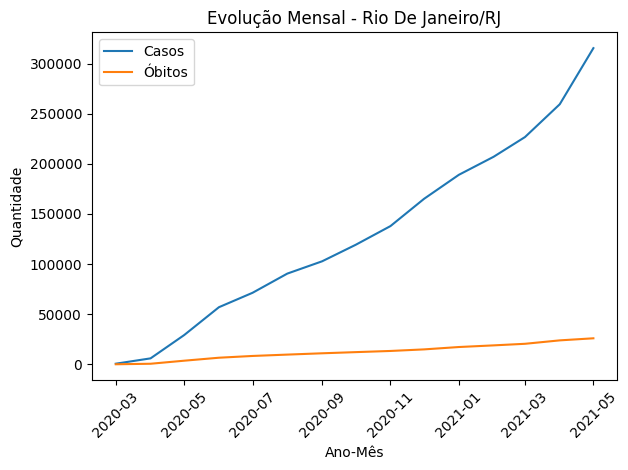

In [10]:
cidade = 'rio de janeiro'
estado = 'RJ'
df_cidade = df[(df['city'].str.lower() == cidade.lower()) & (df['state'] == estado)]

plt.plot(df_cidade['ano_mes'], df_cidade['cases'], label='Casos')
plt.plot(df_cidade['ano_mes'], df_cidade['deaths'], label='Óbitos')
plt.title(f'Evolução Mensal - {cidade.title()}/{estado}')
plt.xlabel('Ano-Mês')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### São Paulo

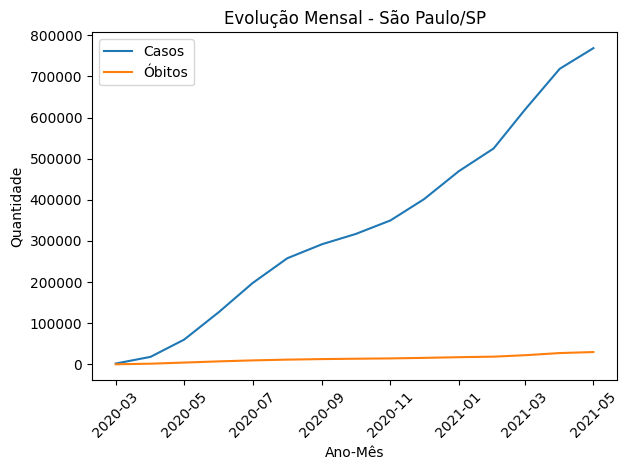

In [11]:
cidade = 'são paulo'
estado = 'SP'
df_cidade = df[(df['city'].str.lower() == cidade.lower()) & (df['state'] == estado)]

plt.plot(df_cidade['ano_mes'], df_cidade['cases'], label='Casos')
plt.plot(df_cidade['ano_mes'], df_cidade['deaths'], label='Óbitos')
plt.title(f'Evolução Mensal - {cidade.title()}/{estado}')
plt.xlabel('Ano-Mês')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## GRÁFICO 4: Letalidade média por estado ao longo do tempo

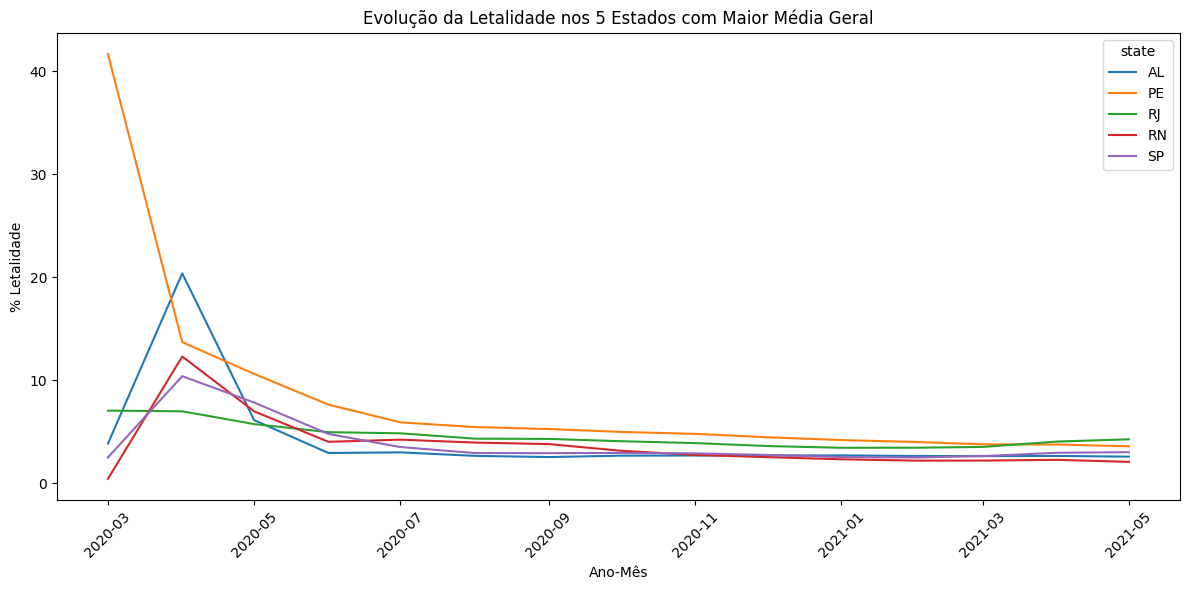

In [13]:
# Calcular letalidade média por estado no período todo
top5_estados = (
    df.groupby('state')['letalidade_percentual']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

# Filtrar apenas os estados do top 5
letalidade_top5 = df[df['state'].isin(top5_estados)]
letalidade_por_estado = letalidade_top5.groupby(['ano_mes', 'state'])['letalidade_percentual'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=letalidade_por_estado, x='ano_mes', y='letalidade_percentual', hue='state')
plt.title('Evolução da Letalidade nos 5 Estados com Maior Média Geral')
plt.ylabel('% Letalidade')
plt.xlabel('Ano-Mês')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
